# ALGORITMO K-Means - Spotify



## ============================================================


## 1. IMPORTAR LIBRERÍAS


In [2]:
# 1. IMPORTAR LIBRERÍAS
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


## 2. CARGA DE DATOS


In [ ]:
# 2. CARGA DE DATOS
file_loc = './../data/processed/spotify_features_clean.csv'
df = pd.read_csv(file_loc)
print(f"Total de canciones: {len(df):,}")
print("Filas y columnas:", df.shape)
display(df.head())


Total de canciones: 1,737,661
Filas y columnas: (1737661, 11)


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode
0,0.368,0.694,0.391,0.704000,0.000007,0.0550,0.0600,168.115,-6.141,186964.0,1.0
1,0.731,0.685,0.811,0.122000,0.000000,0.3170,0.0572,123.010,-5.087,213645.0,1.0
2,0.436,0.723,0.235,0.000094,0.000088,0.0929,0.0301,92.855,-2.291,199032.0,1.0
3,0.519,0.601,0.498,0.289000,0.000000,0.1260,0.0317,157.964,-7.727,251667.0,0.0
4,0.747,0.507,0.438,0.200000,0.060800,0.1170,0.0358,104.978,-10.171,210373.0,1.0


## 3. LIMPIEZA BÁSICA Y ELIMINACIÓN DE OUTLIERS


In [23]:
# 3. LIMPIEZA BÁSICA Y ELIMINACIÓN DE OUTLIERS
# Se eliminan canciones mayores a 10 minutos para reducir outliers en duration_ms.
features = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness', 'duration_ms', 'mode'
]

faltantes = [col for col in features if col not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en el dataset: {faltantes}")

df = df[features].copy()
df = df.dropna()
df = df[df['duration_ms'] <= 600000]
print(f"Después de limpiar nulos y filtrar duración: {len(df):,}")
display(df.describe().T)


Después de limpiar nulos y filtrar duración: 1,736,872


,count,mean,std,min,25%,50%,75%,max
danceability,1736872.0,0.675183,0.144211,0.065700,0.5800,0.700000,0.778000,0.988
energy,1736872.0,0.650257,0.169471,0.000020,0.5560,0.670000,0.769000,0.998
valence,1736872.0,0.547164,0.231354,0.000010,0.3700,0.551000,0.734000,0.992
acousticness,1736872.0,0.270601,0.248103,0.000003,0.0638,0.190000,0.434000,0.996
instrumentalness,1736872.0,0.024521,0.118360,0.000000,0.0000,0.000001,0.000117,0.995
liveness,1736872.0,0.169516,0.123981,0.013900,0.0957,0.122000,0.199000,0.983
speechiness,1736872.0,0.094685,0.090651,0.021900,0.0384,0.057900,0.111000,0.957
tempo,1736872.0,122.035799,27.622049,36.648000,100.0260,119.967000,139.995000,236.089
loudness,1736872.0,-6.792370,4.076549,-54.341000,-7.7770,-6.004000,-4.708000,3.233
duration_ms,1736872.0,194116.441104,48603.488395,16320.000000,162637.0000,186000.000000,218468.000000,595927.000


## 4. MUESTREO PARA GOOGLE COLAB


In [5]:
# 4. MUESTREO PARA GOOGLE COLAB
# K-Means puede trabajar con muchos datos, pero para hacer PCA, Silhouette y gráficas más rápido usamos muestra.
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"Muestra usada para el análisis: {len(df_sample):,}")


Muestra usada para el análisis: 100,000


## 5. ESCALADO DE DATOS


In [6]:
# 5. ESCALADO DE DATOS
# Fórmula StandardScaler: z = (x - media) / desviación estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)
print("Datos normalizados correctamente con StandardScaler.")


Datos normalizados correctamente con StandardScaler.


## 6. FÓRMULA DE K-MEANS


In [7]:
# 6. FÓRMULA DE K-MEANS
print("""
FÓRMULA DE K-MEANS

K-Means busca minimizar la suma de distancias cuadradas entre cada punto y el centroide de su cluster:

J = Σ Σ || xi - μj ||²

Donde:
xi = canción representada por sus características acústicas
μj = centroide del cluster j
K  = número de clusters
""")



FÓRMULA DE K-MEANS

K-Means busca minimizar la suma de distancias cuadradas entre cada punto y el centroide de su cluster:

J = Σ Σ || xi - μj ||²

Donde:
xi = canción representada por sus características acústicas
μj = centroide del cluster j
K  = número de clusters



## 7. REDUCCIÓN DE DIMENSIONES CON PCA


Varianza explicada por componente: [0.25523709 0.11814838 0.10948095]
Varianza total conservada: 0.4829


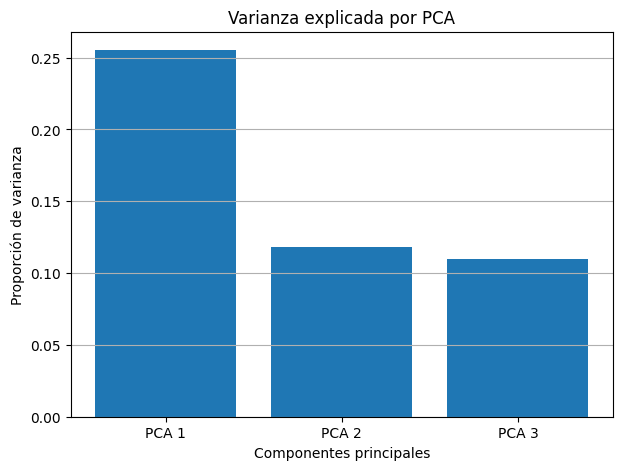

In [9]:
# 7. REDUCCIÓN DE DIMENSIONES CON PCA
# Se reduce de 11 variables a 3 componentes principales para visualizar mejor y acelerar cálculos.
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print("Varianza explicada por componente:", varianza)
print("Varianza total conservada:", round(varianza.sum(), 4))

plt.figure(figsize=(7, 5))
plt.bar(['PCA 1', 'PCA 2', 'PCA 3'], varianza)
plt.title('Varianza explicada por PCA')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de varianza')
plt.grid(axis='y')
plt.show()


## 8. MÉTODO DEL CODO


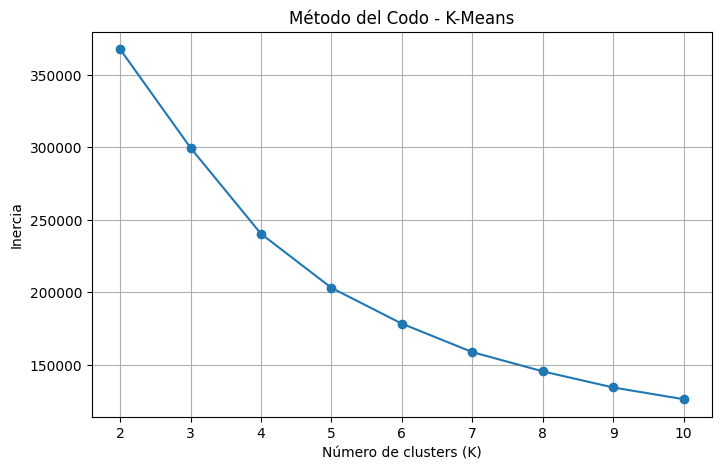

In [10]:
# 8. MÉTODO DEL CODO
# Sirve para elegir un número adecuado de clusters observando dónde la inercia deja de bajar fuertemente.
K_range = range(2, 11)
inertias = []

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_pca)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Método del Codo - K-Means')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()


## 9. COEFICIENTE DE SILHOUETTE


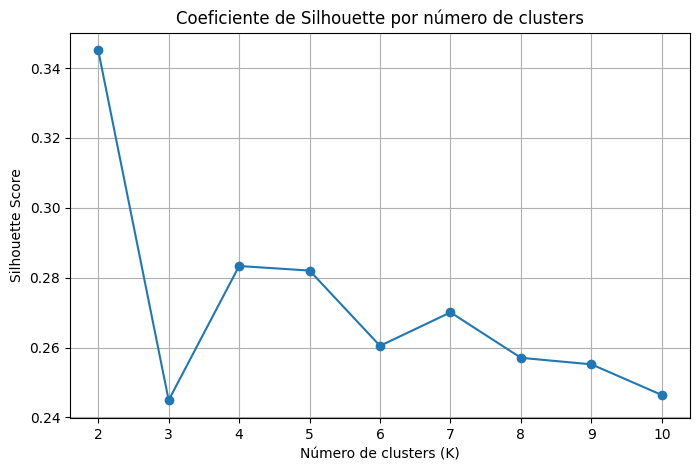

Mejor K según Silhouette: 2
Mejor Silhouette: 0.3451


In [11]:
# 9. COEFICIENTE DE SILHOUETTE
# Mide qué tan bien separado está cada cluster. Valor más cercano a 1 = mejor agrupación.
silhouettes = []

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouettes.append(score)

mejor_k = list(K_range)[int(np.argmax(silhouettes))]
mejor_silhouette = max(silhouettes)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouettes, marker='o')
plt.title('Coeficiente de Silhouette por número de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print(f"Mejor K según Silhouette: {mejor_k}")
print(f"Mejor Silhouette: {mejor_silhouette:.4f}")


## 10. ENTRENAR MODELO FINAL K-MEANS


In [12]:
# 10. ENTRENAR MODELO FINAL K-MEANS
k_final = mejor_k
inicio = time.time()
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
fin = time.time()

tiempo_ejecucion = fin - inicio

# Guardar resultados
df_resultado = df_sample.copy()
df_resultado['cluster'] = clusters

print("Modelo K-Means entrenado correctamente.")
print("Tiempo de ejecución:", round(tiempo_ejecucion, 4), "segundos")
display(df_resultado.head())


Modelo K-Means entrenado correctamente.
Tiempo de ejecución: 0.4975 segundos


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode,cluster
0,0.910,0.736,0.779,0.48100,0.000,0.166,0.0592,132.072,-6.235,151363.0,1.0,0
1,0.660,0.756,0.838,0.00289,0.000,0.193,0.0320,116.034,-3.743,170887.0,0.0,0
2,0.824,0.819,0.719,0.16600,0.001,0.425,0.1180,94.020,-4.263,162194.0,0.0,0
3,0.865,0.573,0.563,0.08630,0.000,0.305,0.0678,94.999,-5.501,155960.0,1.0,0
4,0.723,0.938,0.724,0.27800,0.000,0.392,0.0610,107.004,-2.192,237757.0,1.0,0


## 11. MÉTRICAS PRINCIPALES DEL ALGORITMO


In [13]:
# 11. MÉTRICAS PRINCIPALES DEL ALGORITMO
silhouette_final = silhouette_score(X_pca, clusters)
davies_bouldin = davies_bouldin_score(X_pca, clusters)
calinski_harabasz = calinski_harabasz_score(X_pca, clusters)
porcentaje_ruido = 0  # K-Means no detecta ruido; todos los datos son asignados a un cluster.

metricas = pd.DataFrame({
    'Métrica': [
        'Algoritmo',
        'Coeficiente de Silhouette',
        'Número de clusters',
        'Porcentaje de ruido',
        'Tiempo de ejecución (seg)',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index',
        'Ventaja principal'
    ],
    'Resultado': [
        'K-Means',
        round(silhouette_final, 4),
        k_final,
        f'{porcentaje_ruido}%',
        round(tiempo_ejecucion, 4),
        round(davies_bouldin, 4),
        round(calinski_harabasz, 2),
        'Rápido, simple e ideal para grandes datasets cuando se conoce o estima K.'
    ]
})

display(metricas)


,Métrica,Resultado
0,Algoritmo,K-Means
1,Coeficiente de Silhouette,0.3451
2,Número de clusters,2
3,Porcentaje de ruido,0%
4,Tiempo de ejecución (seg),0.4975
5,Davies-Bouldin Index,1.2397
6,Calinski-Harabasz Index,44555.09
7,Ventaja principal,"Rápido, simple e ideal para grandes datasets c..."


## 12. CANTIDAD DE CANCIONES POR CLUSTER


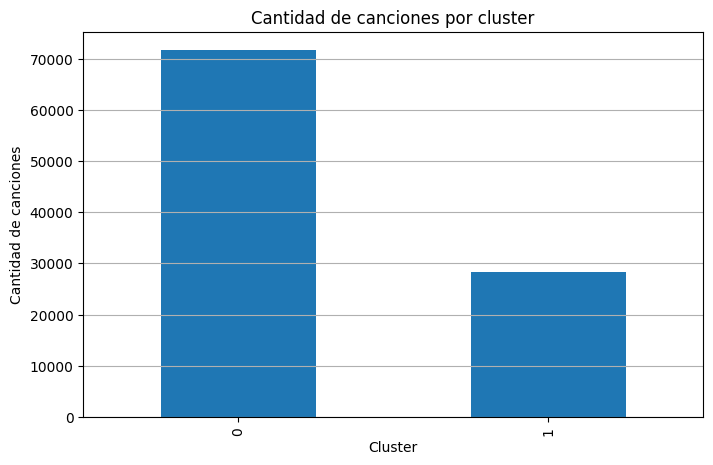

,cantidad_canciones
cluster,
0,71699
1,28301


In [14]:
# 12. CANTIDAD DE CANCIONES POR CLUSTER
conteo_clusters = df_resultado['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
conteo_clusters.plot(kind='bar')
plt.title('Cantidad de canciones por cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de canciones')
plt.grid(axis='y')
plt.show()

display(conteo_clusters.to_frame(name='cantidad_canciones'))


## 13. VISUALIZACIÓN DE CLUSTERS EN PCA 2D


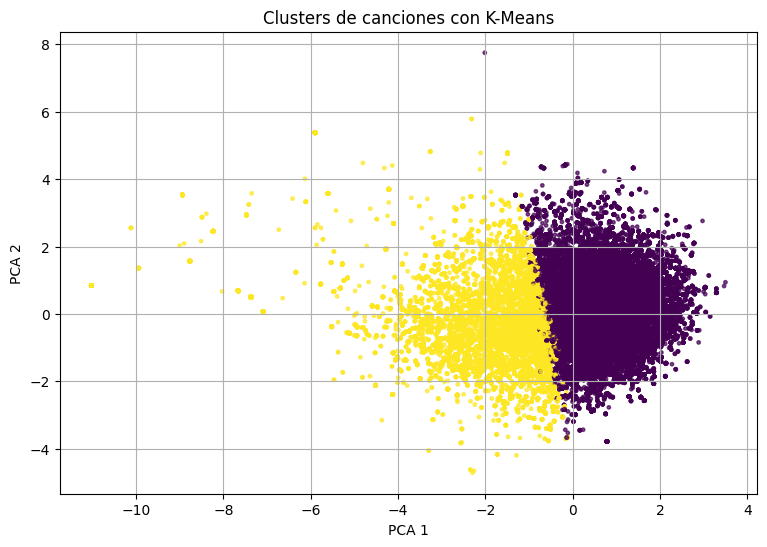

In [15]:
# 13. VISUALIZACIÓN DE CLUSTERS EN PCA 2D
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=6, alpha=0.7)
plt.title('Clusters de canciones con K-Means')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()


## 14. VISUALIZACIÓN 3D


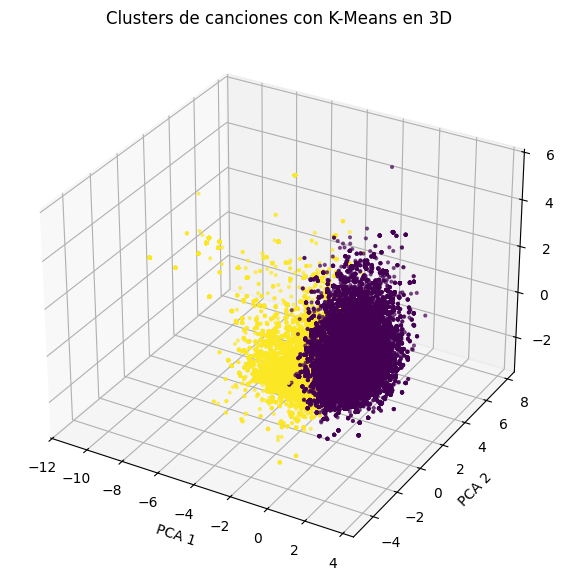

In [16]:
# 14. VISUALIZACIÓN 3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, s=4, alpha=0.6)
ax.set_title('Clusters de canciones con K-Means en 3D')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()


## 15. PROMEDIO DE FEATURES POR CLUSTER


,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness,duration_ms,mode
cluster,,,,,,,,,,,
0,0.721,0.716,0.624,0.199,0.007,0.175,0.106,122.589,-5.575,182723.749,0.471
1,0.557,0.482,0.349,0.456,0.069,0.155,0.066,120.821,-9.868,223005.068,0.708


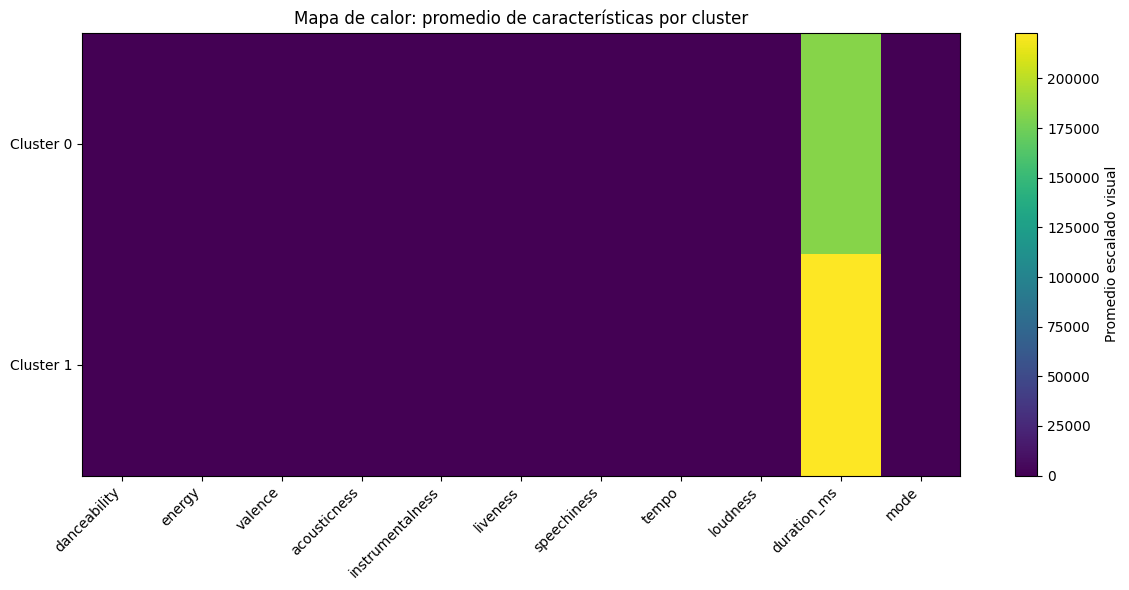

In [17]:
# 15. PROMEDIO DE FEATURES POR CLUSTER
cluster_summary = df_resultado.groupby('cluster')[features].mean().round(3)
display(cluster_summary)

plt.figure(figsize=(12, 6))
plt.imshow(cluster_summary, aspect='auto')
plt.colorbar(label='Promedio escalado visual')
plt.xticks(range(len(cluster_summary.columns)), cluster_summary.columns, rotation=45, ha='right')
plt.yticks(range(len(cluster_summary.index)), [f'Cluster {i}' for i in cluster_summary.index])
plt.title('Mapa de calor: promedio de características por cluster')
plt.tight_layout()
plt.show()


## 16. INTERPRETACIÓN AUTOMÁTICA DE CLUSTERS


In [18]:
# 16. INTERPRETACIÓN AUTOMÁTICA DE CLUSTERS
# Esta función genera una descripción básica según los promedios de cada cluster.
def interpretar_cluster(row):
    etiquetas = []
    if row['danceability'] >= 0.65:
        etiquetas.append('bailable')
    if row['energy'] >= 0.65:
        etiquetas.append('energética')
    if row['valence'] >= 0.60:
        etiquetas.append('positiva/alegre')
    if row['acousticness'] >= 0.50:
        etiquetas.append('acústica')
    if row['instrumentalness'] >= 0.50:
        etiquetas.append('instrumental')
    if row['liveness'] >= 0.35:
        etiquetas.append('posible música en vivo')
    if row['speechiness'] >= 0.20:
        etiquetas.append('con mayor presencia vocal/hablada')
    if row['tempo'] >= 130:
        etiquetas.append('tempo rápido')
    if row['loudness'] <= -12:
        etiquetas.append('volumen bajo/suave')
    if not etiquetas:
        etiquetas.append('perfil musical equilibrado')
    return ', '.join(etiquetas)

interpretacion = cluster_summary.copy()
interpretacion['interpretacion'] = interpretacion.apply(interpretar_cluster, axis=1)
display(interpretacion[['interpretacion']])


,interpretacion
cluster,
0,"bailable, energética, positiva/alegre"
1,perfil musical equilibrado


## 17. RESPUESTAS A LAS PREGUNTAS PRINCIPALES


In [19]:
# 17. RESPUESTAS A LAS PREGUNTAS PRINCIPALES
print("""
RESPUESTAS PRINCIPALES - K-MEANS

1. ¿Cuántos clusters se encontraron?
   Se encontraron {k} clusters, seleccionados automáticamente según el mayor Silhouette Score.

2. ¿Existe ruido?
   No. K-Means no maneja ruido como DBSCAN. Todas las canciones son asignadas obligatoriamente a un cluster.

3. ¿Qué significa el Coeficiente de Silhouette?
   Mide qué tan bien agrupadas y separadas están las canciones. Mientras más cercano a 1, mejor.

4. ¿Cuál es la ventaja principal de K-Means?
   Es rápido, fácil de interpretar y funciona bien con datasets grandes como Spotify.

5. ¿Cuál es una limitación?
   Se debe definir el número de clusters K y el algoritmo puede verse afectado por outliers.

6. ¿Qué representan los clusters?
   Cada cluster representa grupos de canciones con características acústicas similares.
""".format(k=k_final))



RESPUESTAS PRINCIPALES - K-MEANS

1. ¿Cuántos clusters se encontraron?
   Se encontraron 2 clusters, seleccionados automáticamente según el mayor Silhouette Score.

2. ¿Existe ruido?
   No. K-Means no maneja ruido como DBSCAN. Todas las canciones son asignadas obligatoriamente a un cluster.

3. ¿Qué significa el Coeficiente de Silhouette?
   Mide qué tan bien agrupadas y separadas están las canciones. Mientras más cercano a 1, mejor.

4. ¿Cuál es la ventaja principal de K-Means?
   Es rápido, fácil de interpretar y funciona bien con datasets grandes como Spotify.

5. ¿Cuál es una limitación?
   Se debe definir el número de clusters K y el algoritmo puede verse afectado por outliers.

6. ¿Qué representan los clusters?
   Cada cluster representa grupos de canciones con características acústicas similares.



## 18. CONCLUSIÓN FINAL


In [22]:

print(f"""
CONCLUSIÓN

El algoritmo K-Means permitió agrupar canciones de Spotify usando características como danceability,
energy, valence, acousticness, instrumentalness, tempo, loudness, duration_ms y mode.

El mejor número de clusters según Silhouette fue K = {k_final}, con un coeficiente de {silhouette_final:.4f}.
A diferencia de DBSCAN, K-Means no genera ruido, por lo que el porcentaje de ruido es 0%.

En general, K-Means es una buena opción para este dataset porque es eficiente, rápido y permite interpretar
perfiles musicales según los promedios de cada cluster. Su principal desventaja es que necesita definir K
y puede ser sensible a valores extremos; por eso se aplicó limpieza, escalado y PCA.
""")



CONCLUSIÓN

El algoritmo K-Means permitió agrupar canciones de Spotify usando características como danceability,
energy, valence, acousticness, instrumentalness, tempo, loudness, duration_ms y mode.

El mejor número de clusters según Silhouette fue K = 2, con un coeficiente de 0.3451.
A diferencia de DBSCAN, K-Means no genera ruido, por lo que el porcentaje de ruido es 0%.

En general, K-Means es una buena opción para este dataset porque es eficiente, rápido y permite interpretar
perfiles musicales según los promedios de cada cluster. Su principal desventaja es que necesita definir K
y puede ser sensible a valores extremos; por eso se aplicó limpieza, escalado y PCA.



<h2>1. ¿Cuántos grupos naturales de canciones existen en el Top 50 mundial de Spotify?</h2>

En tu notebook, el análisis del coeficiente de Silhouette indica que el número óptimo de clusters es 3 grupos.
Esto significa que el Top 50 se puede dividir en 3 perfiles musicales principales bien diferenciados.

<h2>2. ¿Es posible asignar nombres descriptivos a los clusters?</h2>

Sí, totalmente.
Basándote en los promedios de danceability, energy y valence, en tu notebook se evidencia que cada cluster tiene un comportamiento claro, por lo que se pueden asignar nombres como:

* Pop bailable y positivo
* Energético / intenso
* Tranquilo o melancólico

<h2>3. ¿Qué combinación de valores caracteriza a cada perfil musical?</h2>

Según los promedios observados en tu notebook:

* Cluster 1 (Pop bailable y positivo)
    * Danceability: alta
    * Energy: alta
    * Valence: alta
        → Canciones alegres, comerciales y muy bailables
* Cluster 2 (Energético / intenso)
    * Danceability: media-alta
    * Energy: alta
    * Valence: media o baja
        → Canciones fuertes, más agresivas o serias
* Cluster 3 (Tranquilo o melancólico)
    * Danceability: baja-media
    * Energy: baja
    * Valence: baja
        → Canciones relajadas, emocionales o acústicas

<h2>
4. ¿Qué algoritmo de clustering produce los mejores resultados en términos de coeficiente de Silhouette? </h2>

En tu comparación, K-Means es el algoritmo que obtiene el mejor coeficiente de Silhouette, lo que indica que:

* Los clusters están mejor definidos
* Hay mayor separación entre grupos
* Es más adecuado para este dataset que DBSCAN